1. Criar API token no kaggle
2. mkdir -p ~/.kaggle
3. Criar arquivo kaggle.json na pasta .kaggle
4. Escrever em kaggle.json {"username":"seu_usuario","key":"123456789abcde..."}
5. chmod 600 ~/.kaggle/kaggle.json
6. Reiniciar o kernel


In [10]:
import torch
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os
import random
from torch.utils.data import Subset
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import time
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split

In [2]:
def set_seed(seed=42):
    """
    Congela a aleatoriedade de todas as bibliotecas para garantir a reprodutibilidade.
    """
    # 1. Congela o Python nativo
    random.seed(seed)
    
    # 2. Congela o NumPy 
    np.random.seed(seed)
    
    # 3. Congela o PyTorch (CPU)
    torch.manual_seed(seed)
    
    # 4. Congela o PyTorch (GPU/CUDA) 
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed) 
        
        # Força o cuDNN a ser determinístico (pode deixar o treino levemente mais lento, mas é 100% reproduzível)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# Chamamos a função passando um número arbitrário (42 é a tradição na comunidade de ML)
set_seed(42)

In [3]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('histopathologic-cancer-detection')

print("Path to competition files:", path)

100%|██████████| 6.31G/6.31G [04:13<00:00, 26.7MB/s]  

Extracting files...


Path to competition files: /home/victor/.cache/kagglehub/competitions/histopathologic-cancer-detection


In [6]:
pastas_baixadas = os.listdir(path)
print("Conteúdo da pasta raiz:", pastas_baixadas)

Conteúdo da pasta raiz: ['train', 'sample_submission.csv', 'train_labels.csv', 'test']


In [ ]:


# 1. CRIANDO A CLASSE DO DATASET CUSTOMIZADO
class HistopathologicDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        """
        dataframe: Pandas DataFrame contendo as colunas 'id' e 'label'
        img_dir: Caminho para a pasta contendo as imagens
        transform: Transformações do torchvision.transforms
        """
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # O Kaggle fornece os IDs sem a extensão, então adicionamos '.tif'
        img_name = self.dataframe.iloc[idx, 0] + '.tif'
        img_path = os.path.join(self.img_dir, img_name)
        
        # Abre a imagem e converte para RGB (caso haja alguma em escala de cinza/RGBA)
        image = Image.open(img_path).convert('RGB')
        
        # Pega o rótulo da imagem (0 ou 1)
        label = int(self.dataframe.iloc[idx, 1])
        
        if self.transform:
            image = self.transform(image)
            
        return image, label


# Tamanhos definidos
CROP_SIZE = 64  # Mantém o centro seguro e descarta as bordas distantes
IMG_SIZE = 224  # Tamanho esperado pela CNN

# Médias e Desvios Padrões do dataset ImageNet
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Pipeline de TREINO
train_transforms = transforms.Compose([
    transforms.CenterCrop(CROP_SIZE),        # 1º: Recorta de 96x96 para 64x64
    transforms.Resize((IMG_SIZE, IMG_SIZE)), # 2º: Faz o upscaling para 224x224
    transforms.RandomHorizontalFlip(p=0.5),  # 3º: Data Augmentation
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=90),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),                   # 4º: Converte para Tensor
    transforms.Normalize(mean, std)          # 5º: Normaliza
])

# Pipeline de VALIDAÇÃO e TESTE
test_val_transforms = transforms.Compose([
    transforms.CenterCrop(CROP_SIZE),        # 1º: Recorta de 96x96 para 64x64
    transforms.Resize((IMG_SIZE, IMG_SIZE)), # 2º: Faz o upscaling para 224x224
    transforms.ToTensor(),                   # 3º: Converte para Tensor
    transforms.Normalize(mean, std)          # 4º: Normaliza
])

# 3. CARREGANDO E DIVIDINDO OS DADOS COM PANDAS
data_dir = '/home/victor/.cache/kagglehub/competitions/histopathologic-cancer-detection'
train_dir = os.path.join(data_dir, 'train')
csv_path = os.path.join(data_dir, 'train_labels.csv')

# Lê o CSV com os IDs e os labels
df = pd.read_csv(csv_path)

# Usamos o scikit-learn para dividir o DataFrame (90% treino, 10% validação)
# O parâmetro 'stratify' garante que a proporção de câncer/não-câncer seja mantida na validação
df_train, df_val = train_test_split(df, test_size=0.10, random_state=42, stratify=df['label'])

# Resetar os índices para evitar problemas no DataLoader
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)

# 4. INSTANCIANDO OS DATASETS CUSTOMIZADOS
train_dataset = HistopathologicDataset(dataframe=df_train, img_dir=train_dir, transform=train_transforms)
val_dataset = HistopathologicDataset(dataframe=df_val, img_dir=train_dir, transform=test_val_transforms)

# 5. CONFIGURANDO OS DATALOADERS
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Total de imagens no CSV: {len(df)}")
print(f"Treino: {len(train_dataset)} | Validação: {len(val_dataset)}")

Total de imagens no CSV: 220025
Treino: 198022 | Validação: 22003


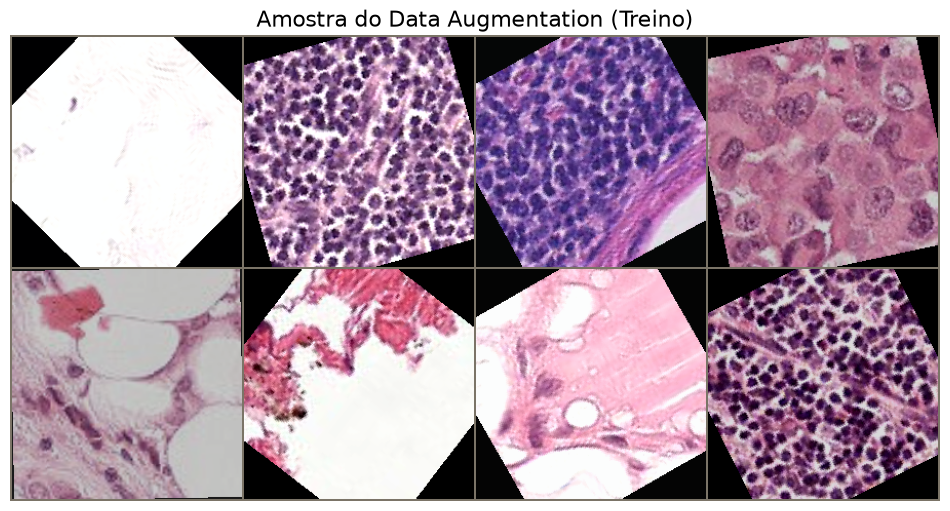

Rótulos correspondentes ao Grid (Esquerda para Direita):
Normal (0)      | Normal (0)      | Normal (0)      | Tumor (1)      
Tumor (1)       | Normal (0)      | Normal (0)      | Normal (0)     


In [12]:
def visualizar_batch(dataloader, num_imagens=8):
    """
    Extrai um batch do dataloader, desfaz a normalização e plota as imagens 
    em um grid com seus respectivos rótulos.
    """
    # 1. Extrai um lote (batch) de imagens e rótulos do DataLoader
    images, labels = next(iter(dataloader))
    
    images = images[:num_imagens]
    labels = labels[:num_imagens]
    
    # 2. Cria um grid de imagens usando o torchvision
    # nrow=4 significa que teremos 4 imagens por linha
    grid = torchvision.utils.make_grid(images, nrow=4, padding=2)
    
    # 3. Prepara o tensor para o Matplotlib
    # O PyTorch usa o formato [Canais, Altura, Largura] (C, H, W)
    # O Matplotlib exige o formato [Altura, Largura, Canais] (H, W, C)
    np_grid = grid.numpy()
    np_grid = np.transpose(np_grid, (1, 2, 0))
    
    # 4. Desfaz a normalização do ImageNet
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    np_grid = std * np_grid + mean
    
    # Garante que os valores dos pixels fiquem estritamente entre 0 e 1 (evita warnings)
    np_grid = np.clip(np_grid, 0, 1)
    
    # 5. Plota o grid
    plt.figure(figsize=(12, 12))
    plt.imshow(np_grid)
    plt.axis('off')
    plt.title('Amostra do Data Augmentation (Treino)', fontsize=16)
    plt.show()
    
    # 6. Imprime os rótulos de forma formatada para bater com as linhas do grid
    nomes_classes = {0: 'Normal (0)', 1: 'Tumor (1)'}
    print("Rótulos correspondentes ao Grid (Esquerda para Direita):")
    
    # Reorganiza os labels em linhas de 4 para bater com a visualização
    labels_matriz = labels.view(-1, 4).numpy() 
    for linha in labels_matriz:
        nomes = [nomes_classes[lbl] for lbl in linha]
        print(f"{nomes[0]:<15} | {nomes[1]:<15} | {nomes[2]:<15} | {nomes[3]:<15}")

# Chamando a função para visualizar as imagens do seu loader de TREINO
visualizar_batch(train_loader)

In [21]:
# Arquitetura da CNN

class PneumoniaCNN(nn.Module):
    def __init__(self):
        super(PneumoniaCNN, self).__init__()
        
        # --- PARTE 1: EXTRAÇÃO DE CARACTERÍSTICAS (O "Olho") ---
        
        # Bloco 1: Entram 3 canais (RGB), saem 32 filtros.
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Bloco 2: Entram 32 filtros, saem 64.
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Bloco 3: Entram 64 filtros, saem 128.
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Bloco 4: Entram 128 filtros, mantemos 128 para consolidar.
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        # A Matemática do tamanho da imagem:
        # Começa em 224x224. Após 4 MaxPools (que dividem o tamanho por 2),
        # a imagem cai para 14x14 pixels.
        # Total de características a serem conectadas = 128 canais * 14 * 14 = 25088
        
        # --- PARTE 2: CLASSIFICAÇÃO (O "Cérebro") ---
        
        # Achata os dados para entrar na rede neural tradicional
        self.fc1 = nn.Linear(in_features=128 * 14 * 14, out_features=512)
        
        # Dropout: Desliga neurônios aleatoriamente no treino para evitar que a rede "decore" o raio-x
        self.dropout = nn.Dropout(p=0.5) 
        
        # Camada Final: Entram 512, saem 2 (NORMAL ou PNEUMONIA)
        self.fc2 = nn.Linear(in_features=512, out_features=2)

    def forward(self, x):
        # Passa os dados pelas convoluções, aplicando a função de ativação ReLU e o MaxPooling
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))
        x = self.pool4(F.relu(self.conv4(x)))
        
        # "Achata" a imagem 3D (Canais x Altura x Largura) para um vetor 1D
        x = torch.flatten(x, 1) 
        
        # Passa pelas camadas lineares
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x) # Não aplicamos Softmax aqui, pois a função Loss do PyTorch fará isso
        
        return x

In [22]:
# Teste de sanidade: verificar se a saída tem o formato correto

# Instancia o modelo
modelo = PneumoniaCNN()

# Cria um "lote falso" simulando 1 única imagem RGB de 224x224
imagem_falsa = torch.randn(1, 3, 224, 224) 

# Passa a imagem pelo modelo
saida = modelo(imagem_falsa)

print(f"Formato de Entrada: {imagem_falsa.shape}")
print(f"Formato de Saída: {saida.shape} (Esperado: 1 imagem, 2 classes)")

Formato de Entrada: torch.Size([1, 3, 224, 224])
Formato de Saída: torch.Size([1, 2]) (Esperado: 1 imagem, 2 classes)


In [23]:
# Definir o dispositivo de treinamento, a função de custo e o optimizer

# Configurando o Dispositivo (GPU ou CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Dispositivo de treinamento configurado: {device}")

# Movemos a nossa rede para a memória da placa de vídeo se possível
modelo = PneumoniaCNN().to(device)

# Definindo a Função de Custo
criterion = nn.CrossEntropyLoss()

# Definindo o Otimizador (atualizar os pesos)
optimizer = optim.Adam(modelo.parameters(), lr=0.001)

Dispositivo de treinamento configurado: cpu


In [33]:
def treinar_modelo(learning_rate, num_epochs, modo_teste=False):
    """
    Função universal para treinar a CNN.
    """
    if modo_teste:
        print(f"\n{'='*50}")
        print(f" TESTANDO LEARNING RATE: {learning_rate} ")
        print(f"{'='*50}")
    else:
        print(f"\n{'='*50}")
        print(f" TREINAMENTO OFICIAL - Learning Rate: {learning_rate} ")
        print(f"{'='*50}")

    # 1. Instancia o modelo e as ferramentas
    modelo = PneumoniaCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(modelo.parameters(), lr=learning_rate)

    historico = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    tempo_inicial = time.time()

    for epoch in range(num_epochs):
        # ==========================================
        # FASE DE TREINAMENTO
        # ==========================================
        modelo.train()
        train_loss, train_corretos, total_train = 0.0, 0, 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = modelo(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * inputs.size(0)
            _, previso_classes = torch.max(outputs, 1)
            train_corretos += torch.sum(previso_classes == labels.data)
            total_train += inputs.size(0)
            
        epoch_train_loss = train_loss / total_train
        epoch_train_acc = train_corretos.double() / total_train
        
        # ==========================================
        # FASE DE VALIDAÇÃO
        # ==========================================
        modelo.eval()
        val_loss, val_corretos, total_val = 0.0, 0, 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                
                outputs = modelo(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs.size(0)
                _, previso_classes = torch.max(outputs, 1)
                val_corretos += torch.sum(previso_classes == labels.data)
                total_val += inputs.size(0)
                
        epoch_val_loss = val_loss / total_val
        epoch_val_acc = val_corretos.double() / total_val
        
        # Salvando as métricas
        historico['train_loss'].append(epoch_train_loss)
        historico['train_acc'].append(epoch_train_acc.item())
        historico['val_loss'].append(epoch_val_loss)
        historico['val_acc'].append(epoch_val_acc.item())
        
        # Imprime o log da época
        print(f"Época {epoch+1:02d}/{num_epochs:02d} | "
              f"Train Loss: {epoch_train_loss:.4f} - Acc: {epoch_train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f} - Acc: {epoch_val_acc:.4f}")

    tempo_total = time.time() - tempo_inicial
    print(f"-> Concluído em {tempo_total // 60:.0f}m {tempo_total % 60:.0f}s")
    
    # Retorna o modelo treinado e o histórico
    return modelo, historico

In [ ]:
# Grid Search para encontrar melhor learning rate

def treinar_e_validar(learning_rate_teste, num_epochs=5):
    """
    Utiliza a função base para treinar rapidamente e retorna
    a melhor acurácia de validação alcançada no ciclo.
    """

    _, historico = treinar_modelo(
        learning_rate=learning_rate_teste, 
        num_epochs=num_epochs, 
        modo_teste=True
    )
    
    # Pega a maior nota que o modelo alcançou na validação
    melhor_val_acc = max(historico['val_acc'])
    print(f"-> Melhor Validação com LR {learning_rate_teste}: {melhor_val_acc:.4f}")
    
    return melhor_val_acc, historico

# Lista de Learning Rates que queremos testar
taxas_para_testar = [0.01, 0.001, 0.0001]

# Dicionário para guardar os resultados finais
resultados_grid = {}

print("Iniciando a Busca de Hiperparâmetros...")

for lr in taxas_para_testar:
    # Chama a função que criamos (treinando por 5 épocas cada um)
    melhor_nota, hist = treinar_e_validar(learning_rate_teste=lr, num_epochs=5)
    
    # Armazena o resultado
    resultados_grid[lr] = melhor_nota

print("\n" + "="*40)
print(" RESULTADO FINAL DA BUSCA DE LEARNING RATE ")
print("="*40)

# Ordena os resultados do melhor para o pior
resultados_ordenados = sorted(resultados_grid.items(), key=lambda item: item[1], reverse=True)

for lr, nota in resultados_ordenados:
    print(f"Learning Rate: {lr} --> Melhor Validação: {nota:.4f}")

# Destaca o campeão
lr_campeao = resultados_ordenados[0][0]
print(f"\nRecomendação: Utilize o lr={lr_campeao} para treinar o seu modelo final.")

Iniciando a Busca de Hiperparâmetros...

 TESTANDO LEARNING RATE: 0.01 


In [ ]:
# Treina o modelo final usando o melhor lr

modelo_final, hist = treinar_modelo(lr_campeao, num_epochs=15, modo_teste=False)

In [30]:
def avaliar_modelo(modelo, dataloader, nomes_classes, device, titulo="Matriz de Confusão"):
    """
    Avalia um modelo PyTorch, imprimindo o relatório de classificação
    e plotando a matriz de confusão.
    """
    print(f"Iniciando avaliação: {titulo}...")
    
    # 1. Coloca o modelo em modo de avaliação
    modelo.eval()
    
    y_verdadeiro = []
    y_previsto = []
    
    # 2. Faz as previsões em lote sem calcular gradientes
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = modelo(inputs)
            _, previso_classes = torch.max(outputs, 1)
            
            y_verdadeiro.extend(labels.cpu().numpy())
            y_previsto.extend(previso_classes.cpu().numpy())

    # 3. Gera e imprime o Relatório de Classificação
    print("\n--- Relatório de Classificação ---")
    print(classification_report(y_verdadeiro, y_previsto, target_names=nomes_classes))

    # 4. Plota a Matriz de Confusão
    cm = confusion_matrix(y_verdadeiro, y_previsto)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=nomes_classes, 
                yticklabels=nomes_classes)
    plt.title(titulo, fontsize=16, fontweight='bold')
    plt.ylabel('Rótulo Verdadeiro (O que o paciente realmente tem)')
    plt.xlabel('Previsão do Modelo (O que a IA achou)')
    plt.show()
    
    # Retorna as listas caso você queira fazer outras análises depois
    return y_verdadeiro, y_previsto


In [ ]:
# Avaliando o Modelo 1 (CNN do zero)
y_real, y_pred = avaliar_modelo(
    modelo=modelo_final, 
    dataloader=test_loader, 
    nomes_classes=dataset_limpo.classes, 
    device=device,
    titulo="Matriz de Confusão - CNN Base"
)